In [1]:
#Packages to Import

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})


#Some Code to Compute measures of mixing


def autocorr_func_1d(x):
    """Compute full autocorrelation function for 1D array x."""
    x = np.asarray(x)
    n = len(x)
    x -= x.mean()
    # unbiased variance
    c0 = np.dot(x, x) / n
    # full autocovariance
    acov = np.correlate(x, x, mode="full")[n-1:] / np.arange(n, 0, -1)
    return acov / c0

def ess(x, max_lag=None):
    """
    Effective Sample Size via initial positive sequence:
      ESS = N / [1 + 2 * sum_{k=1}^K rho_k]
    where K is the last lag before rho_k+rho_{k+1} < 0.
    """
    acf = autocorr_func_1d(x)
    N = len(x)
    # choose max_lag if not set
    if max_lag is None:
        max_lag = N//2
    rho = acf[1:max_lag]
    # find where successive pairs go negative
    K = max_lag
    for k in range(0, len(rho)-1, 2):
        if rho[k] + rho[k+1] < 0:
            K = k+1
            break
    tau = 1 + 2 * np.sum(rho[:K])
    return N / tau


def msjd(samples: np.ndarray) -> float:
    """
    Mean‑Squared Jumping Distance.

    Parameters
    ----------
    samples : array_like, shape (N, d)
        Markov‑chain states X₁,…,X_N.

    Returns
    -------
    msjd : float
        Average squared Euclidean distance between successive states.
    """
    diffs = np.diff(samples, axis=0)      # shape (N-1, d)
    return np.mean(np.sum(diffs**2, axis=1))


In [11]:
#Example 1: Perturbed Gaussian Target

#Model Dimension and Parameter Size

NmParaEx1 = 2 #Dimension of the Gaussian Target

cov0 = 5
gam = 1.5
CovEx1 = np.diag([cov0* (j**(-gam)) for j in list(range(1,NmParaEx1+1))])

k0 = 3
k0inv = k0**(-1)
c0inv = CovEx1[0,0]**(-1)
m = -1

PotEx1 = lambda X : .5*X[0]*(k0inv - c0inv)*X[0] - k0inv*m*X[0]

  0%|          | 0/5 [00:00<?, ?it/s]

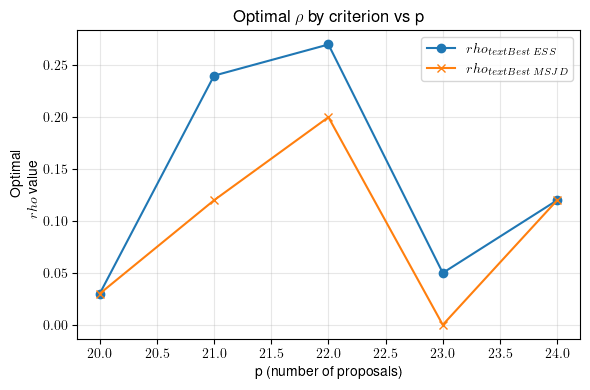

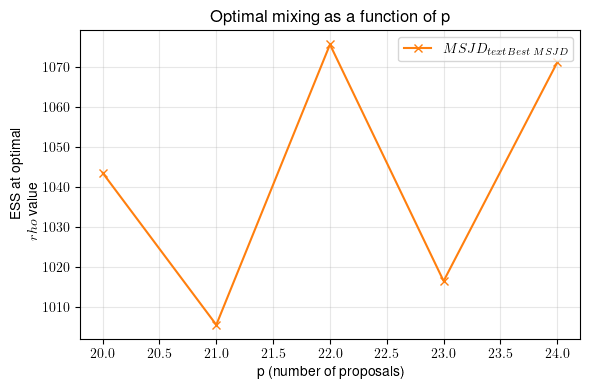

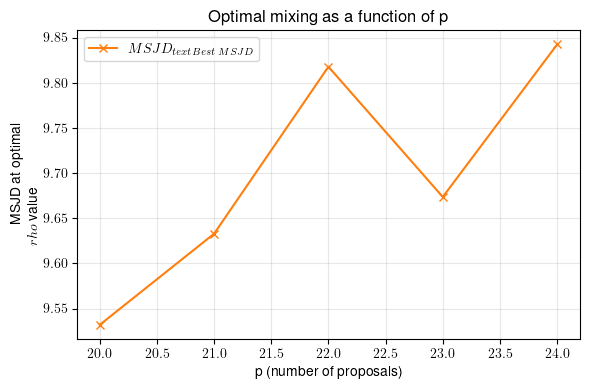

In [14]:
#Optimal tuning of rho for Example 1

pI = 20
pStep = 1
pF = 25


delRho = .01
burnIn = 1000
NumSamps = 2000

pLstEx1 = []
ESSrhoBestLstEx1 = []
ESSBestLstEx1 = []
MSJDrhoBestLstEx1 = []
MSJDBestLstEx1 = []

q0Ex1 = np.zeros(NmParaEx1)
for p in tqdm(range(pI,pF,pStep)):
    rho = 0
    rhoBestESS = 0
    rhoBestMSJD = 0
    ESSBest = 0
    MSJDBest = 0
    while(rho < 1):
        curSamp = MpCN(q0Ex1,NmParaEx1,CovEx1,rho,PotEx1,p,NumSamps)
        ESSCur = ess(curSamp[burnIn:,0])
        MSJDCur = msjd(curSamp[burnIn:])
        if ESSCur > ESSBest:
            ESSBest = ESSCur
            rhoBestESS = rho
        if MSJDCur > MSJDBest:
            MSJDBest = MSJDCur
            rhoBestMSJD = rho
        rho = rho + delRho
    pLstEx1.append(p)
    ESSBestLstEx1.append(ESSBest)
    ESSrhoBestLstEx1.append(rhoBestESS)
    MSJDBestLstEx1.append(MSJDBest)
    MSJDrhoBestLstEx1.append(rhoBestMSJD)

#Saving Experiment

FileNmBase= "Data/Gaussian/"
ExpDes = "p_range_(" + str(pI) + "_"+ str(pF) +  "_"+ str(pStep) + ")rho_range_" + str(delRho)
csvFileNm = FileNmBase + ExpDes + ".csv"

writeCSV(csvFileNm,[pLstEx1,ESSBestLstEx1, ESSrhoBestLstEx1, MSJDBestLstEx1,MSJDrhoBestLstEx1])


#Some Plots

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx1, ESSrhoBestLstEx1, marker="o", linestyle="-", label=r"$\\rho_{\\text{Best\,ESS}}$", color="tab:blue")
ax.plot(pLstEx1, MSJDrhoBestLstEx1, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx1, ESSBestLstEx1, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"ESS at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx1, MSJDBestLstEx1, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"MSJD at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Mixing as a function of rho
#Experiment 1

pmd = 1000

delRho = .01
burnIn = 1000
NumSamps = 20000

ESSLstp100Ex1 = []
MSJDLstp100Ex1 = []
rhoLstp100Ex1 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex1.append(rho)
    curSamp = MpCN(q0Ex1,NmParaEx1,CovEx1,rho,PotEx1,p,NumSamps)
    ESSLstp100Ex1.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex1.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex1, ESSLstp100Ex1, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex1, MSJDLstp100Ex1, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

In [5]:
#Example 2: Statistical Inversion for the function f(x,y) = xy

#Specification of the forward problem (MM)
zdata = 6
sig = 1
fFn = lambda X : X[0]*X[1]
fFnStr = "xy"

NumParmsEx2 = 2

#LogLikihood function
PotEx2 = lambda X : (2* sig**2)**(-1) *(fFn(X) - zdata )**2

#Specifying the covariance
CovEVs = [3,2]
Tth = 2*np.pi/9

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(CovEVs)

#CovEx2 = Rot.T @ Diag @ Rot

CovEx2 = Diag

  0%|          | 0/4 [00:00<?, ?it/s]

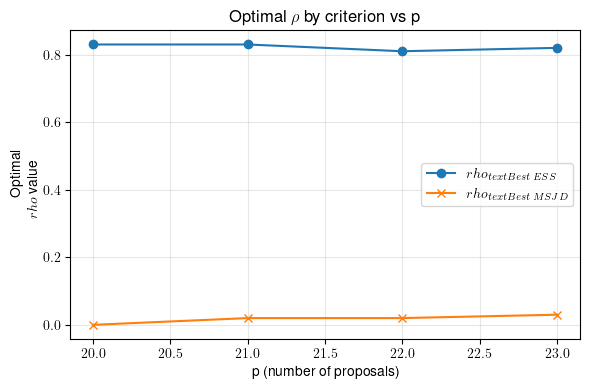

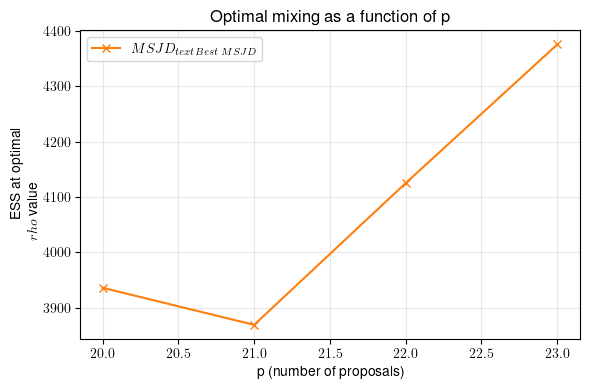

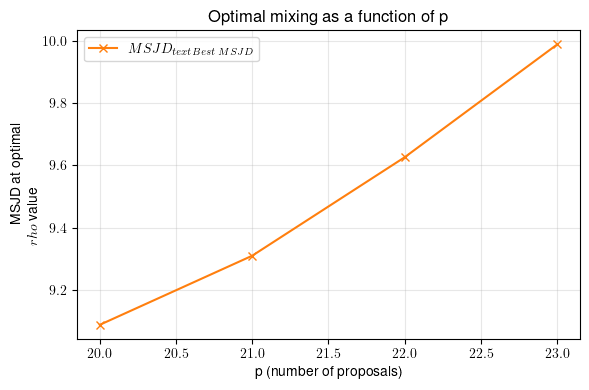

In [8]:
#Optimal tuning of rho for Example 2

pI = 20
pStep = 1
pF = 24


delRho = .01
burnIn = 1000
NumSamps = 20000

pLstEx2 = []
ESSrhoBestLstEx2 = []
ESSBestLstEx2 = []
MSJDrhoBestLstEx2 = []
MSJDBestLstEx2 = []

q0Ex2 = np.zeros(NumParmsEx2)
for p in tqdm(range(pI,pF,pStep)):
    rho = 0
    rhoBestESS = 0
    rhoBestMSJD = 0
    ESSBest = 0
    MSJDBest = 0
    while(rho < 1):
        curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,p,NumSamps)
        ESSCur = ess(curSamp[burnIn:,0])
        MSJDCur = msjd(curSamp[burnIn:])
        if ESSCur > ESSBest:
            ESSBest = ESSCur
            rhoBestESS = rho
        if MSJDCur > MSJDBest:
            MSJDBest = MSJDCur
            rhoBestMSJD = rho
        rho = rho + delRho
    pLstEx2.append(p)
    ESSBestLstEx2.append(ESSBest)
    ESSrhoBestLstEx2.append(rhoBestESS)
    MSJDBestLstEx2.append(MSJDBest)
    MSJDrhoBestLstEx2.append(rhoBestMSJD)


#Saving Experiment

FileNmBase= "Data/Inversion_Toy/"
ExpDes = "p_range_(" + str(pI) + "_"+ str(pF) +  "_"+ str(pStep) + ")rho_range_" + str(delRho)
csvFileNm = FileNmBase + ExpDes + ".csv"

writeCSV(csvFileNm,[pLstEx2,ESSBestLstEx2, ESSrhoBestLstEx2, MSJDBestLstEx2,MSJDrhoBestLstEx2])


#Some Plots

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx2, ESSrhoBestLstEx2, marker="o", linestyle="-", label=r"$\\rho_{\\text{Best\,ESS}}$", color="tab:blue")
ax.plot(pLstEx2, MSJDrhoBestLstEx2, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx2, ESSBestLstEx2, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"ESS at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx2, MSJDBestLstEx2, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"MSJD at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Mixing as a function of rho
#Experiment 2

pmd = 10

delRho = .01
burnIn = 1000
NumSamps = 20000

ESSLstp100Ex2 = []
MSJDLstp100Ex2 = []
rhoLstp100Ex2 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex2.append(rho)
    curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,pmd,NumSamps)
    ESSLstp100Ex2.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex2.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, ESSLstp100Ex2, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, MSJDLstp100Ex2, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()